In [1]:
# ---------------- Import Libraries ----------------
import numpy as np  # numerical operations
import pandas as pd  # data handling
import matplotlib.pyplot as plt  # plotting
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ---------------- Load Dataset ----------------
dataset = pd.read_csv('Wine.csv')  # load dataset
X = dataset.iloc[:, 0:13].values  # features
y = dataset.iloc[:, 13].values  # target

In [3]:
# ---------------- Train-Test Split ----------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)  # split data

In [4]:
# ---------------- Feature Scaling ----------------
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)  # scale training
X_test = sc.transform(X_test)  # scale test

In [7]:
# ---------------- Kernel PCA ----------------
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components=2, kernel='rbf')  # apply nonlinear PCA using RBF kernel
X_train = kpca.fit_transform(X_train)  # transform training data
X_test = kpca.transform(X_test)  # transform test data

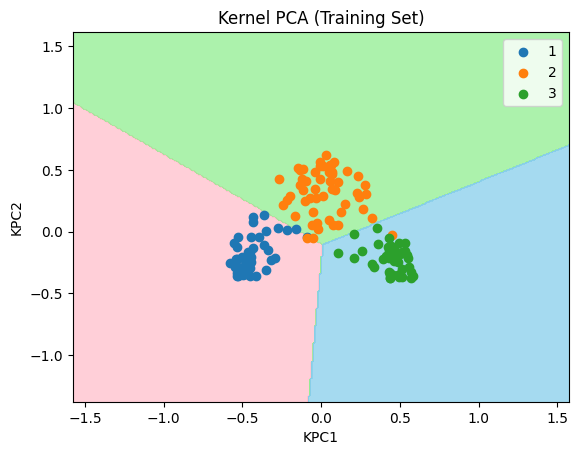

In [9]:
# ---------------- Visualization ----------------
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
                     np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01))  # create grid

from sklearn.linear_model import LogisticRegression
temp_model = LogisticRegression(max_iter=1000)
temp_model.fit(X_train, y_train)  # temporary model for boundary

plt.contourf(X1, X2, temp_model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('pink','lightgreen','skyblue')))  # decision regions

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set==j,0], X_set[y_set==j,1], label=j)  # plot points

plt.title('Kernel PCA (Training Set)')
plt.xlabel('KPC1')
plt.ylabel('KPC2')
plt.legend()
plt.show()

The Kernel PCA plot shows three well-separated clusters, indicating that the nonlinear transformation has effectively captured complex patterns and improved class separation.

In [10]:
# ---------------- Model Evaluation ----------------
from sklearn.metrics import accuracy_score

def model_accuracy(model, X_train, y_train, X_test, y_test):  # train and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

In [11]:
# ---------------- Models ----------------
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

acclog=[]; accsvml=[]; accsvmnl=[]; accknn=[]; accnav=[]; accdes=[]; accrf=[]

# run models
acclog.append(model_accuracy(LogisticRegression(max_iter=1000), X_train, y_train, X_test, y_test))
accsvml.append(model_accuracy(SVC(kernel='linear'), X_train, y_train, X_test, y_test))
accsvmnl.append(model_accuracy(SVC(kernel='rbf'), X_train, y_train, X_test, y_test))
accknn.append(model_accuracy(KNeighborsClassifier(n_neighbors=5), X_train, y_train, X_test, y_test))
accnav.append(model_accuracy(GaussianNB(), X_train, y_train, X_test, y_test))
accdes.append(model_accuracy(DecisionTreeClassifier(), X_train, y_train, X_test, y_test))
accrf.append(model_accuracy(RandomForestClassifier(n_estimators=100), X_train, y_train, X_test, y_test))

In [12]:
# ---------------- Result Table ----------------
result = pd.DataFrame(index=['Kernel PCA'], columns=['Logistic','SVMl','SVMnl','KNN','Navie','Decision','Random'])

result.loc['Kernel PCA','Logistic'] = acclog[0]
result.loc['Kernel PCA','SVMl'] = accsvml[0]
result.loc['Kernel PCA','SVMnl'] = accsvmnl[0]
result.loc['Kernel PCA','KNN'] = accknn[0]
result.loc['Kernel PCA','Navie'] = accnav[0]
result.loc['Kernel PCA','Decision'] = accdes[0]
result.loc['Kernel PCA','Random'] = accrf[0]

In [13]:
result

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Kernel PCA,1.0,1.0,1.0,1.0,1.0,0.944444,1.0


After applying Kernel PCA, most models achieved perfect accuracy (1.0), showing that the nonlinear transformation has made the data highly separable and easy to classify.